In [1]:
import numpy as np
import qnm
import sxs
import h5py
from scipy import interpolate
import pickle

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal
from itertools import combinations_with_replacement

In [2]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
plt.rcParams['figure.max_open_warning'] = 0

plt.rcParams['text.usetex']        = True

# plt.rcParams['mathtext.fontset']  = 'stix'
# plt.rcParams['font.family']       = 'STIXGeneral'

plt.rcParams['font.size']         = 14
plt.rcParams['axes.linewidth']    = 1
plt.rcParams['axes.labelsize']    = plt.rcParams['font.size']
plt.rcParams['axes.titlesize']    = 1.5*plt.rcParams['font.size']
plt.rcParams['legend.fontsize']   = plt.rcParams['font.size']
plt.rcParams['xtick.labelsize']   = plt.rcParams['font.size']
plt.rcParams['ytick.labelsize']   = plt.rcParams['font.size']
plt.rcParams['xtick.major.size']  = 3
plt.rcParams['xtick.minor.size']  = 3
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.major.size']  = 3
plt.rcParams['ytick.minor.size']  = 3
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['ytick.minor.width'] = 1

plt.rcParams['legend.frameon']             = False
plt.rcParams['legend.loc']                 = 'center left'
plt.rcParams['contour.negative_linestyle'] = 'solid'

In [ ]:
def wfs(res, res_qc, res0, res_qc0, label, NR_re=None, NR_im=None, t_NR=None):
    
    omega, _, _ = qnm.modes_cache(s=-2, l=2, m=2, n=0)(a=np.abs(res[0].af))
    f_rd_fundamental = (np.real(omega) / res[0].Mf) / (2.0 * np.pi)
    tau_rd_fundamental = -1.0 / (np.imag(omega)) * res[0].Mf

    tau = res[0].t_NR - res[0].t_peak
    tau_cut = res[0].t_NR_cut - res[0].t_peak

    NR_phi = res[0].NR_phi
    NR_r, NR_i = res[0].NR_r, res[0].NR_i
    NR_f = res[0].NR_freq

    NR_amp = res[0].NR_amp
    NR_r, NR_i = res[0].NR_r, res[0].NR_i

    nc_re, nc_im = res[2].wf_r, res[2].wf_i
    nc_re0, nc_im0 = res0[2].wf_r, res0[2].wf_i
    qc_re, qc_im = res_qc[2].wf_r, res_qc[2].wf_i
    qc_re0, qc_im0 = res_qc0[2].wf_r, res_qc0[2].wf_i

    qc_amp = np.sqrt(qc_re**2 + qc_im**2)
    qc_amp0 = np.sqrt(qc_re0**2 + qc_im0**2)
    nc_amp = np.sqrt(nc_re**2 + nc_im**2)
    nc_amp0 = np.sqrt(nc_re0**2 + nc_im0**2)

    qc_phase = np.unwrap(np.angle(qc_re - 1j*qc_im))
    qc_phase0 = np.unwrap(np.angle(qc_re0 - 1j*qc_im0))
    nc_phase = np.unwrap(np.angle(nc_re - 1j*nc_im))
    nc_phase0 = np.unwrap(np.angle(nc_re0 - 1j*nc_im0))

    if len(qc_phase) != len(tau_cut):
        qc_freq = np.gradient(qc_phase[:-1], tau_cut)*(2.0*np.pi)
    else:
        qc_freq = np.gradient(qc_phase, tau_cut)*(2.0*np.pi)
    if len(qc_phase0) != len(tau_cut):
        qc_freq0 = np.gradient(qc_phase0[:-1], tau_cut)*(2.0*np.pi)
    else:
        qc_freq0 = np.gradient(qc_phase0, tau_cut)*(2.0*np.pi)
    nc_freq = np.gradient(nc_phase, tau_cut)*(2.0*np.pi)
    nc_freq0 = np.gradient(nc_phase0, tau_cut)*(2.0*np.pi)

    label_data = 'h_{22}'

    COL = {
        'NR': 'k',
        'RatExp':'#cc0033',
        'HypTan': 'royalblue',
        't_peak': 'royalblue',
        'f_overt': 'darkorange',
        'f_ring': 'forestgreen',
    }

    alpha_std = 1
    alpha_med = 0.8
    alpha_low = 0.9

    LS = {
        't': '--',
        'f': '--',
        'Global': '--',
        'Local': '-',
    }

    LW = {
        'small': 1.25,
        'medium': 1.2,
        'std': 1.8,
        'large': 2.5,
    }

    FONTS = {
        'legend': 18,
        'labels': 23,
    }

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    ax1, ax2, ax3, ax4 = axes.flat

    plot_std = dict(c=COL['NR'], lw=LW['std'], alpha=alpha_std, ls='-')
    vline_peak = dict(lw=LW['small'], alpha=alpha_std, ls=LS['t'])

    ax1.plot(tau, NR_r, **plot_std)
    if len(qc_phase0) != len(tau_cut):
        ax1.plot(tau_cut, qc_re0[:-1], c=COL['HypTan'], lw=LW['large'], alpha=alpha_med, linestyle=LS['Global'])
    else:
        ax1.plot(tau_cut, qc_re0, c=COL['HypTan'], lw=LW['large'], alpha=alpha_med, linestyle=LS['Global'])
    if len(qc_phase) != len(tau_cut):
        ax1.plot(tau_cut, qc_re[:-1], c=COL['HypTan'], lw=LW['large'], alpha=alpha_low, linestyle=LS['Local'])
    else:
        ax1.plot(tau_cut, qc_re, c=COL['HypTan'], lw=LW['large'], alpha=alpha_low, linestyle=LS['Local'])
    ax1.plot(tau_cut, nc_re0, c=COL['RatExp'], lw=LW['large'], alpha=alpha_std, linestyle=LS['Global'])
    ax1.plot(tau_cut, nc_re, c=COL['RatExp'], lw=LW['large'], alpha=alpha_std, linestyle=LS['Local'])
    ax1.axvline(0.0, c=COL['t_peak'], **vline_peak)
    ax1.set_ylabel(r'$\mathit{Re}(%s)$' % (label_data,), fontsize=FONTS['labels'])

    NR_r_cut_nc = res[0].NR_r_cut
    NR_r_cut_nc0 = res0[0].NR_r_cut
    NR_r_cut_qc = res_qc[0].NR_r_cut
    NR_r_cut_qc0 = res_qc0[0].NR_r_cut

    ax3.plot(tau_cut, (qc_re0 - NR_r_cut_qc0), c=COL['HypTan'], lw=LW['large'], alpha=alpha_med, linestyle=LS['Global'])
    ax3.plot(tau_cut, (qc_re - NR_r_cut_qc), c=COL['HypTan'], lw=LW['large'], alpha=alpha_low, linestyle=LS['Local'])
    ax3.plot(tau_cut, (nc_re0 - NR_r_cut_nc0), c=COL['RatExp'], lw=LW['large'], alpha=alpha_std, linestyle=LS['Global'])
    ax3.plot(tau_cut, (nc_re - NR_r_cut_nc), c=COL['RatExp'], lw=LW['large'], alpha=alpha_std, linestyle=LS['Local'])
    ax3.axvline(0.0, c=COL['t_peak'], **vline_peak)
    ax3.set_ylabel(r'$\delta\mathit{Re}(%s)$' % (label_data,), fontsize=FONTS['labels'])
    ax3.set_xlabel(r'$t - t_{\rm{mrg}} \, [M]$', fontsize=FONTS['labels'])
    ax3.axhspan(ymin=-1e-3, ymax=1e-3, color='gray', alpha=0.3)

    ax2.semilogy(tau, NR_amp * np.exp((tau) / tau_rd_fundamental), c=COL['NR'], lw=LW['std'], alpha=alpha_std, ls='-')
    ax2.semilogy(tau_cut, qc_amp0 * np.exp((tau_cut / tau_rd_fundamental)), c=COL['HypTan'], lw=LW['large'], alpha=alpha_med, ls=LS['Global'])
    ax2.semilogy(tau_cut, qc_amp * np.exp((tau_cut / tau_rd_fundamental)), c=COL['HypTan'], lw=LW['large'], alpha=alpha_low, ls=LS['Local'])
    ax2.semilogy(tau_cut, nc_amp0 * np.exp((tau_cut / tau_rd_fundamental)), c=COL['RatExp'], lw=LW['large'], alpha=alpha_std, ls=LS['Global'])
    ax2.semilogy(tau_cut, nc_amp * np.exp((tau_cut / tau_rd_fundamental)), c=COL['RatExp'], lw=LW['large'], alpha=alpha_std, ls=LS['Local'])
    ax2.axvline(0.0, c=COL['t_peak'], **vline_peak)
    ax2.set_ylabel(r'$\mathit{A_{22}(t)} \cdot \rm{e}^{t/\tau_{22}}$', fontsize=FONTS['labels'])
    ax2.set_ylim(5e-2, 2e0)

    ax4.plot(tau, NR_f, c=COL['NR'], lw=LW['std'], alpha=alpha_std, ls='-')
    ax4.plot(tau_cut, qc_freq0, c=COL['HypTan'], lw=LW['large'], alpha=alpha_med, ls=LS['Global'])
    ax4.plot(tau_cut, qc_freq, c=COL['HypTan'], lw=LW['large'], alpha=alpha_low, ls=LS['Local'])
    ax4.plot(tau_cut, nc_freq0, c=COL['RatExp'], lw=LW['large'], alpha=alpha_std, ls=LS['Global'])
    ax4.plot(tau_cut, nc_freq, c=COL['RatExp'], lw=LW['large'], alpha=alpha_std, ls=LS['Local'])
    ax4.axhline(f_rd_fundamental, c=COL['f_ring'], lw=LW['small'], alpha=alpha_std, ls=LS['f'])
    ax4.axvline(0.0, c=COL['t_peak'], **vline_peak)
    ax4.set_xlabel(r'$t - t_{\rm{mrg}} \, [M]$', fontsize=FONTS['labels'])
    ax4.set_ylabel(r'$\mathit{f_{22}\,(t)}$', fontsize=FONTS['labels'])
    ax4.set_ylim(0, f_rd_fundamental*1.5)

    plt.rcParams['legend.frameon'] = True
    
    custom_lines_1 = [
        Line2D([0], [0], color=COL['NR'], lw=LW['std'], label=r'$\mathrm{NR}$'),
        Line2D([0], [0], color=COL['HypTan'], lw=LW['large'], label=r'$\it{HypTan}$'),
        Line2D([0], [0], color=COL['RatExp'], lw=LW['large'], label=r'$\it{RatExp}$')
    ]
    ax1.legend(handles=custom_lines_1, loc='lower right', fontsize=FONTS['legend'])

    custom_lines_2 = [
        Line2D([0], [0], color='gray', lw=LW['large'], ls=LS['Local'], label='Local Fit'),
        Line2D([0], [0], color='gray', lw=LW['large'], ls=LS['Global'], label='Global Fit')
    ]
    ax3.legend(handles=custom_lines_2, loc='lower right', fontsize=FONTS['legend'])
    
    ax2.legend(handles=[Line2D([0], [0], color=COL['t_peak'], lw=LW['small'], ls=LS['t'], label=r'$t_{\rm mrg}$')], loc='lower right', fontsize=FONTS['legend'])

    ax4.legend(handles=[Line2D([0], [0], color=COL['f_ring'], lw=LW['small'], ls=LS['f'], label=r'$\mathit{f_{22}}$')], loc='lower right', fontsize=FONTS['legend'])

    for ax in (ax1, ax2, ax3, ax4):
        ax.set_xlim(-10, 80)

    ax1.set_xticklabels([])
    ax2.set_xticklabels([])

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.subplots_adjust(hspace=0, wspace=0.27)
    if label is not None:
        plt.savefig(f'{label}.pdf', dpi=300)
    plt.show()
    plt.close()

### RIT

/home/nishkal/anaconda3/envs/non_circular_ringdown/lib/python3.12/site-packages/pyRingGW-2.7.0-py3.12-linux-x86_64.egg/pyRing/utils.py:66: UserWarning: * The `surfinBH` package is not automatically installed due to possible conflicts. If you wish to use its functionalities, it needs to be installed separately.
  warnings.warn("* The `surfinBH` package is not automatically installed due to possible conflicts. If you wish to use its functionalities, it needs to be installed separately.")
/home/nishkal/anaconda3/envs/non_circular_ringdown/lib/python3.12/site-packages/pyRingGW-2.7.0-py3.12-linux-x86_64.egg/pyRing/utils.py:330: UserWarning: The requested functionality requires data not included in the package. Please set a $PYRING_PREFIX variable which contains the path to such data. This can be done by setting 'export PYRING_PREFIX= yourpath' in your ~/.bashrc file. Typically, PYRING_PREFIX contains the path to the clone of the repository containing the source code.
  warnings.warn("The re

Destination path /home/nishkal/.cache/qnm/data-0.4.0.tar.bz2 already exists, use overwrite=True to force an overwrite.


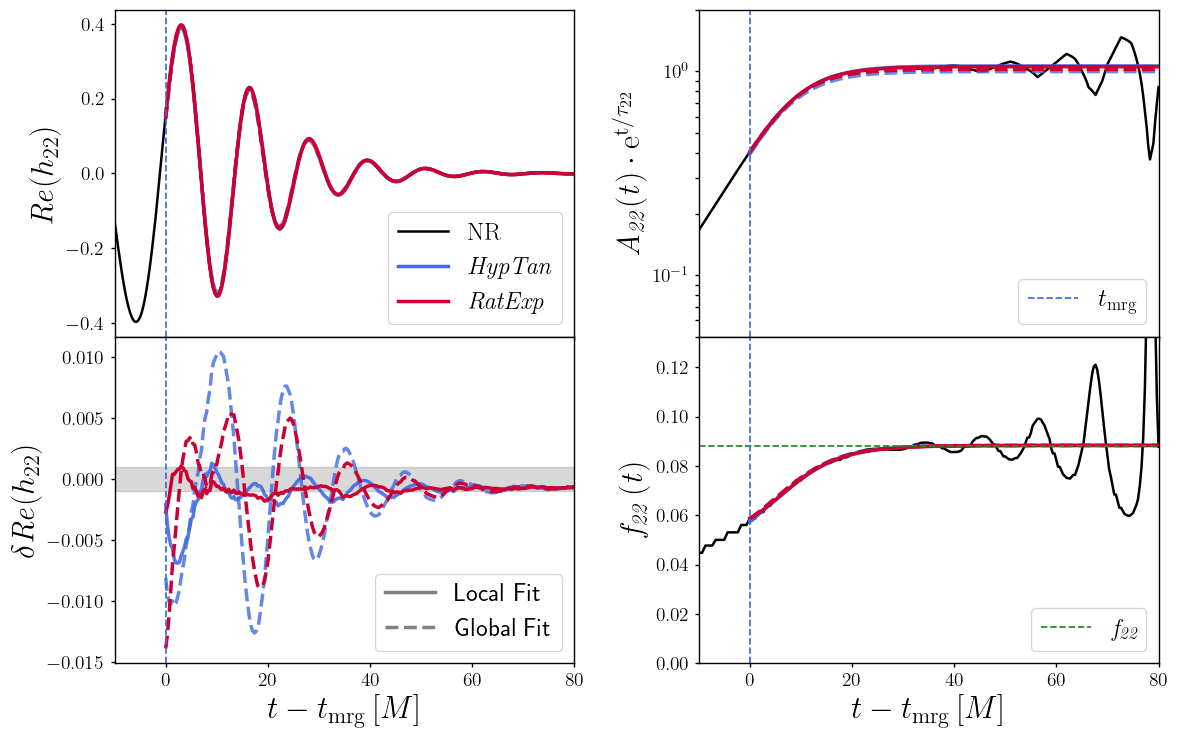

In [4]:
res_qc0 = pickle.load(open('../src/output/nc_qc_fits/outputs/RIT_QC_0/NR_sim.pkl','rb'))
res_qc = pickle.load(open('../src/output/nc_qc_fits/outputs/RIT_QC/NR_sim.pkl','rb'))
res_nc0 = pickle.load(open('../src/output/nc_qc_fits/outputs/RIT_NC_0/NR_sim.pkl','rb'))
res_nc = pickle.load(open('../src/output/nc_qc_fits/outputs/RIT_NC/NR_sim.pkl','rb'))
wfs(res_nc, res_qc, res_nc0, res_qc0, label='RIT_1334')

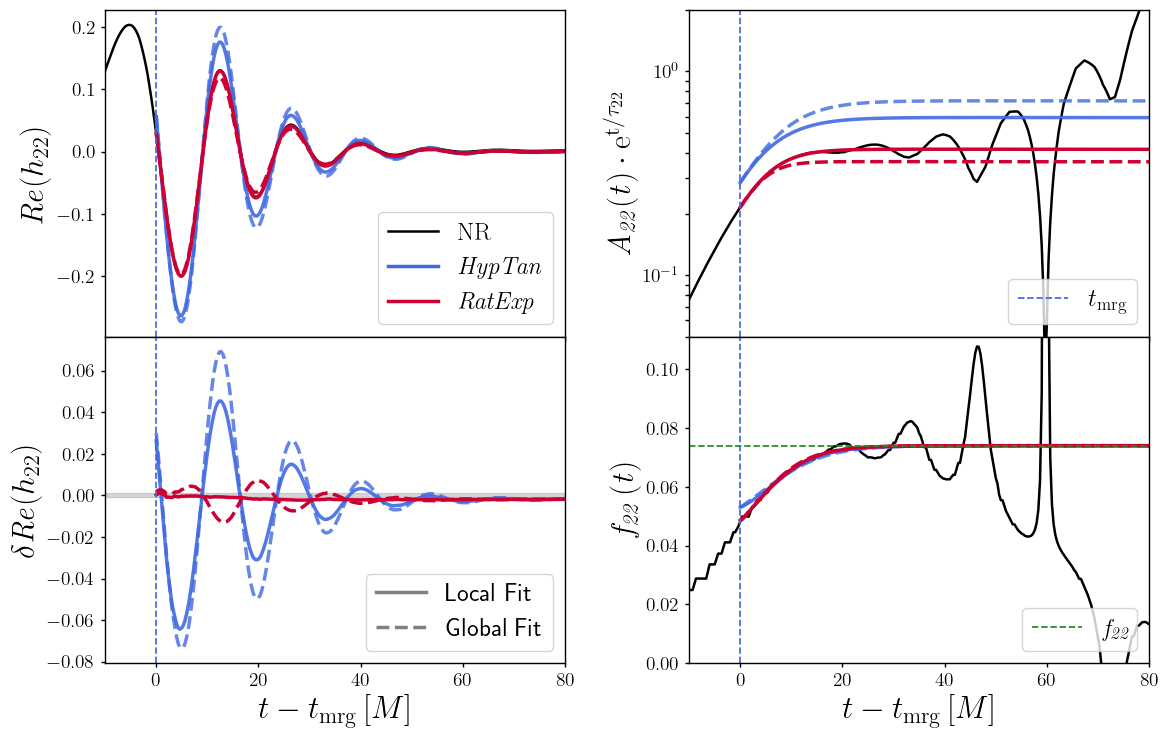

In [5]:
res_qc0 = pickle.load(open('../src/output/nc_qc_fits/outputs/RIT_QC_2_0/NR_sim.pkl','rb'))
res_qc = pickle.load(open('../src/output/nc_qc_fits/outputs/RIT_QC_2/NR_sim.pkl','rb'))
res_nc0 = pickle.load(open('../src/output/nc_qc_fits/outputs/RIT_NC_2_0/NR_sim.pkl','rb'))
res_nc = pickle.load(open('../src/output/nc_qc_fits/outputs/RIT_NC_2/NR_sim.pkl','rb'))
wfs(res_nc, res_qc, res_nc0, res_qc0, label='RIT_1479')

### SXS

In [ ]:
def wfs(t_NR, NR_rs, NR_is, q, nu, Mf, af, nc_coeffs, qc_coeffs, nc_coeffs0, qc_coeffs0, t_peak, A_22_mrg, omg_peak, A_22_mrg_ddot, alpha_1, alpha_21, omega_1, label=None):
   
    alpha_2 = alpha_21 + alpha_1
    delta_omega = omega_1 - Mf*omg_peak

    omega, _, _ = qnm.modes_cache(s=-2, l=2, m=2, n=0)(a=np.abs(af))
    f_rd_fundamental = (np.real(omega) / Mf) / (2.0 * np.pi)
    tau_rd_fundamental = -1.0 / (np.imag(omega)) * Mf

    tM_start, tM_end = -15, 80

    t_min, t_max = t_peak + tM_start, t_peak + tM_end
    idx_min, idx_max = np.where((t_NR - t_min)>=0)[0][0], np.where((t_NR - t_max)<=0)[0][-1]

    tau = t_NR[idx_min:idx_max] - t_peak
    NR_amp = np.abs(NR_rs - 1j*NR_is)[idx_min:idx_max]
    NR_phi = np.unwrap(np.angle(NR_rs - 1j*NR_is))[idx_min:idx_max]
    NR_r, NR_i = NR_rs[idx_min:idx_max], NR_is[idx_min:idx_max]
    NR_f = np.gradient(NR_phi, t_NR[idx_min:idx_max])*(2.0*np.pi)

    def qc_amplitude(c3A, tau_arr):
        c2A = (alpha_2 - alpha_1) / 2
        c1A = A_22_mrg * alpha_1 * np.cosh(c3A)**2 / c2A
        c4A = A_22_mrg - c1A * np.tanh(c3A)
        amp = c1A * np.tanh(c2A * tau_arr / Mf + c3A) + c4A
        return amp
    
    def qc_phases(c3P, c4P, tau_arr, phi_0):
        c2P = alpha_2 - alpha_1
        c1P = delta_omega * (1 + c3P + c4P) / (c2P * (c3P + 2 * c4P))
        phi = -c1P * np.log((1 + c3P * np.exp(-c2P * tau_arr) + c4P * np.exp(-2 * c2P * tau_arr)) / (1 + c3P + c4P))
        return -phi + omega_1 * tau_arr / Mf + phi_0

    qc_amp = qc_amplitude(qc_coeffs['c3A'], tau) * np.exp(-alpha_1 * tau / Mf)
    qc_phase = qc_phases(qc_coeffs['c3p'], qc_coeffs['c4p'], tau, qc_coeffs['phi_0'])
    qc_re, qc_im = -qc_amp * np.cos(qc_phase), qc_amp * np.sin(qc_phase)
    qc_freq = np.gradient(qc_phase, tau)*(2.0*np.pi)

    qc_amp0 = qc_amplitude(qc_coeffs0['c3A'], tau) * np.exp(-alpha_1 * tau / Mf) * 1.001
    qc_phase0 = qc_phases(qc_coeffs0['c3p'], qc_coeffs0['c4p'], tau, qc_coeffs0['phi_0']) * 1.01
    qc_re0, qc_im0 = -qc_amp0 * np.cos(qc_phase0), qc_amp0 * np.sin(qc_phase0)
    qc_freq0 = np.gradient(qc_phase0, tau)*(2.0*np.pi)
    
    def nc_amplitude(c2A, c3A, tau_arr):
        c5A = -A_22_mrg_ddot / (A_22_mrg * alpha_1**2) + c2A / alpha_1 * (np.exp(c3A) - 1) / (np.exp(c3A) + 1)
        c1A = c5A * alpha_1 / c2A * A_22_mrg**c5A * np.exp(-c3A) * (1 + np.exp(c3A))**2
        c4A = A_22_mrg**c5A - c1A / (1 + np.exp(c3A))
        amp = (c1A / (1 + np.exp(-c2A * tau_arr / Mf + c3A)) + c4A)**(1 / c5A)
        return amp 

    def nc_phases(c2P, c3P, c4P, tau_arr, phi_0):
        c1P = (1 + c3P + c4P) / (c2P * (c3P + 2 * c4P)) * delta_omega
        phi = -c1P * np.log((1 + c3P * np.exp(-c2P * tau_arr / Mf) + c4P * np.exp(-2 * c2P * tau_arr / Mf)) / (1 + c3P + c4P))
        return -phi + omega_1 * tau_arr / Mf + phi_0

    nc_amp = nc_amplitude(nc_coeffs['c2A'], nc_coeffs['c3A'], tau) * np.exp(-alpha_1 * tau / Mf)
    nc_phase = nc_phases(nc_coeffs['c2p'], nc_coeffs['c3p'], nc_coeffs['c4p'], tau, nc_coeffs['phi_0'])
    nc_re, nc_im = -nc_amp * np.cos(nc_phase), nc_amp * np.sin(nc_phase)
    nc_freq = np.gradient(nc_phase, tau)*(2.0*np.pi)

    nc_amp0 = nc_amplitude(nc_coeffs0['c2A'], nc_coeffs0['c3A'], tau) * np.exp(-alpha_1 * tau / Mf) * 1.0001
    nc_phase0 = nc_phases(nc_coeffs0['c2p'], nc_coeffs0['c3p'], nc_coeffs0['c4p'], tau, nc_coeffs0['phi_0']) * 1.001
    nc_re0, nc_im0 = -nc_amp0 * np.cos(nc_phase0), nc_amp0 * np.sin(nc_phase0)
    nc_freq0 = np.gradient(nc_phase0, tau)*(2.0*np.pi)

    label_data = 'h_{22}'

    COL = {
        'NR': 'k',
        'RatExp':'#cc0033',
        'HypTan': 'royalblue',
        't_peak': 'royalblue',
        'f_overt': 'darkorange',
        'f_ring': 'forestgreen',
    }

    alpha_std = 1
    alpha_med = 0.8
    alpha_low = 0.9

    LS = {
        't': '--',
        'f': '--',
        'Global': '--',
        'Local': '-',
    }

    LW = {
        'small': 1.25,
        'medium': 1.2,
        'std': 1.8,
        'large': 2.5,
    }

    FONTS = {
        'legend': 18,
        'labels': 23,
    }

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    ax1, ax2, ax3, ax4 = axes.flat

    plot_std = dict(c=COL['NR'], lw=LW['std'], alpha=alpha_std, ls='-')
    vline_peak = dict(lw=LW['small'], alpha=alpha_std, ls=LS['t'])

    ax1.plot(tau, NR_r, **plot_std)
    ax1.plot(tau[(tau>=0) & (tau<80)], qc_re0[(tau>=0) & (tau<80)], c=COL['HypTan'], lw=LW['large'], alpha=alpha_med, linestyle=LS['Global'])
    ax1.plot(tau[(tau>=0) & (tau<80)], qc_re[(tau>=0) & (tau<80)], c=COL['HypTan'], lw=LW['large'], alpha=alpha_low, linestyle=LS['Local'])
    ax1.plot(tau[(tau>=0) & (tau<80)], nc_re0[(tau>=0) & (tau<80)], c=COL['RatExp'], lw=LW['large'], alpha=alpha_std, linestyle=LS['Global'])
    ax1.plot(tau[(tau>=0) & (tau<80)], nc_re[(tau>=0) & (tau<80)], c=COL['RatExp'], lw=LW['large'], alpha=alpha_std, linestyle=LS['Local'])
    ax1.axvline(0.0, c=COL['t_peak'], **vline_peak)
    ax1.set_ylabel(r'$\mathit{Re}(%s)$' % (label_data,), fontsize=FONTS['labels'])

    tM_start, tM_end = 0, 80
    
    t_min, t_max = t_peak + tM_start, t_peak + tM_end
    idx_min, idx_max = np.where((t_NR - t_min)>=0)[0][0], np.where((t_NR - t_max)<=0)[0][-1]
    ax3.plot(tau[(tau>=0) & (tau<80)], (qc_re0[(tau>=0) & (tau<80)] - NR_rs[idx_min:idx_max]), c=COL['HypTan'], lw=LW['large'], alpha=alpha_med, linestyle=LS['Global'])
    ax3.plot(tau[(tau>=0) & (tau<80)], (qc_re[(tau>=0) & (tau<80)] - NR_rs[idx_min:idx_max]), c=COL['HypTan'], lw=LW['large'], alpha=alpha_low, linestyle=LS['Local'])
    ax3.plot(tau[(tau>=0) & (tau<80)], (nc_re0[(tau>=0) & (tau<80)] - NR_rs[idx_min:idx_max]), c=COL['RatExp'], lw=LW['large'], alpha=alpha_std, linestyle=LS['Global'])
    ax3.plot(tau[(tau>=0) & (tau<80)], (nc_re[(tau>=0) & (tau<80)] - NR_rs[idx_min:idx_max]), c=COL['RatExp'], lw=LW['large'], alpha=alpha_std, linestyle=LS['Local'])
    ax3.axvline(0.0, c=COL['t_peak'], **vline_peak)
    ax3.set_ylabel(r'$\delta\mathit{Re}(%s)$' % (label_data,), fontsize=FONTS['labels'])
    ax3.set_xlabel(r'$t - t_{\rm{mrg}} \, [M]$', fontsize=FONTS['labels'])
    ax3.axhspan(ymin=-1e-3, ymax=1e-3, color='gray', alpha=0.3)

    ax2.semilogy(tau, NR_amp * np.exp((tau) / tau_rd_fundamental), c=COL['NR'], lw=LW['std'], alpha=alpha_std, ls='-')
    ax2.semilogy(tau[(tau>=0) & (tau<80)], qc_amp0[(tau>=0) & (tau<80)] * np.exp((tau[(tau>=0) & (tau<80)] / tau_rd_fundamental)), c=COL['HypTan'], lw=LW['large'], alpha=alpha_med, ls=LS['Global'])
    ax2.semilogy(tau[(tau>=0) & (tau<80)], qc_amp[(tau>=0) & (tau<80)] * np.exp((tau[(tau>=0) & (tau<80)] / tau_rd_fundamental)), c=COL['HypTan'], lw=LW['large'], alpha=alpha_low, ls=LS['Local'])
    ax2.semilogy(tau[(tau>=0) & (tau<80)], nc_amp0[(tau>=0) & (tau<80)] * np.exp((tau[(tau>=0) & (tau<80)] / tau_rd_fundamental)), c=COL['RatExp'], lw=LW['large'], alpha=alpha_std, ls=LS['Global'])
    ax2.semilogy(tau[(tau>=0) & (tau<80)], nc_amp[(tau>=0) & (tau<80)] * np.exp((tau[(tau>=0) & (tau<80)] / tau_rd_fundamental)), c=COL['RatExp'], lw=LW['large'], alpha=alpha_std, ls=LS['Local'])
    ax2.axvline(0.0, c=COL['t_peak'], **vline_peak)
    ax2.set_ylabel(r'$\mathit{A_{22}(t)} \cdot \rm{e}^{t/\tau_{22}}$', fontsize=FONTS['labels'])
    ax2.set_ylim(5e-2, 2e0)

    ax4.plot(tau, NR_f, c=COL['NR'], lw=LW['std'], alpha=alpha_std, ls='-')
    ax4.plot(tau[(tau>=0) & (tau<80)], qc_freq0[(tau>=0) & (tau<80)], c=COL['HypTan'], lw=LW['large'], alpha=alpha_med, ls=LS['Global'])
    ax4.plot(tau[(tau>=0) & (tau<80)], qc_freq[(tau>=0) & (tau<80)], c=COL['HypTan'], lw=LW['large'], alpha=alpha_low, ls=LS['Local'])
    ax4.plot(tau[(tau>=0) & (tau<80)], nc_freq0[(tau>=0) & (tau<80)], c=COL['RatExp'], lw=LW['large'], alpha=alpha_std, ls=LS['Global'])
    ax4.plot(tau[(tau>=0) & (tau<80)], nc_freq[(tau>=0) & (tau<80)], c=COL['RatExp'], lw=LW['large'], alpha=alpha_std, ls=LS['Local'])
    ax4.axhline(f_rd_fundamental, c=COL['f_ring'], lw=LW['small'], alpha=alpha_std, ls=LS['f'])
    ax4.axvline(0.0, c=COL['t_peak'], **vline_peak)
    ax4.set_xlabel(r'$t - t_{\rm{mrg}} \, [M]$', fontsize=FONTS['labels'])
    ax4.set_ylabel(r'$\mathit{f_{22}\,(t)}$', fontsize=FONTS['labels'])
    ax4.set_ylim(0, f_rd_fundamental*1.5)

    plt.rcParams['legend.frameon'] = True
    
    custom_lines_1 = [
        Line2D([0], [0], color=COL['NR'], lw=LW['std'], label=r'$\mathrm{NR}$'),
        Line2D([0], [0], color=COL['HypTan'], lw=LW['large'], label=r'$\it{HypTan}$'),
        Line2D([0], [0], color=COL['RatExp'], lw=LW['large'], label=r'$\it{RatExp}$')
    ]
    ax1.legend(handles=custom_lines_1, loc='lower right', fontsize=FONTS['legend'])

    custom_lines_2 = [
        Line2D([0], [0], color='gray', lw=LW['large'], ls=LS['Local'], label='Local Fit'),
        Line2D([0], [0], color='gray', lw=LW['large'], ls=LS['Global'], label='Global Fit')
    ]
    ax3.legend(handles=custom_lines_2, loc='lower right', fontsize=FONTS['legend'])
    
    ax2.legend(handles=[Line2D([0], [0], color=COL['t_peak'], lw=LW['small'], ls=LS['t'], label=r'$t_{\rm mrg}$')], loc='lower right', fontsize=FONTS['legend'])

    ax4.legend(handles=[Line2D([0], [0], color=COL['f_ring'], lw=LW['small'], ls=LS['f'], label=r'$\mathit{f_{22}}$')], loc='lower right', fontsize=FONTS['legend'])

    for ax in (ax1, ax2, ax3, ax4):
        ax.set_xlim(-10, 80)

    ax1.set_xticklabels([])
    ax2.set_xticklabels([])

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.subplots_adjust(hspace=0, wspace=0.27)
    if label is not None:
        plt.savefig(f'{label}.pdf', dpi=300)
    plt.show()
    plt.close()

In [7]:
sim = sxs.load('SXS:BBH:2527/Lev3', extrapolation_order=2)
wf = sim.h
metadata = sim.metadata
index = wf.index(2, 2)
wf = wf[:, index]
t_NR = wf.t

Loading SXS simulations using latest tag 'v3.0.0', published at 2025-05-14T18:17:30Z.


In [8]:
q=metadata.initial_mass2/metadata.initial_mass1
nu=q/(1+q)**2
Mf = 0.9515839467331337
af = 0.6863698356953697
A_22_mrg = 0.4018489407448092
omg_peak = 0.3608692222555589
A_22_mrg_ddot = -0.0009911982882747
nc_coeffs = {'c3A': -1.836968926874,
          'c3p': 4.227093534181,
          'c4p': 3.129754039384,
          'c2A': -0.197843826582,
          'c2p': 0.158243704538,
          'phi_0': 0.787784829016}
qc_coeffs = {'c3A': -0.428858318486,
          'c3p': 4.128430507046,
          'c4p': 1.745991389183,
          'phi_0': 0.789025588653}
emrg = 0.9982453131874697
bmrg = 2.8519596941980967
t_peak = 16389.45254725883
alpha_1 = 0.08109284148976856 
alpha_21 = 0.16405380358250368
omega_1 = 0.5293241819119422

In [9]:
def generate_global_coeffs(nu, emrg, bmrg, phi_0_nc=0.0, phi_0_qc=0.0):
    
    Q_values = [
        nu * 32.0 - 7.0,
        emrg * 21.792405855131097 - 19.96025031862279,
        bmrg * 1.3439145490527014 - 3.5738030997813306
    ]

    fit_coeffs = {
        'c_2_A': [
            -0.6042335818452162, 0.0286253346555564, 0.0937977405828041, 1.743249873768155, 
            0.010242645784703, -0.032112506321183, -0.0416202653685786, 0.6666709209967016, 
            -0.7818352059682518, -0.7694142181937809, -0.01590377725159, 0.013545814609477, 
            -0.0194188195639271, 0.0281745042749282, 0.0265308815444966, 0.0190944485366076, 
            0.2679474048251403, -0.8745728615664976, 0.7189075007916391, -0.1584944064696176
        ],
        'c_2_phi': [
            0.0992274874400841, -0.0153793984571265, -0.063256857518701, 0.0848298913560179, 
            -0.010669116298205, -0.0126021006926368, -0.0053259103308755, 0.1039530246665291, 
            0.0499446766972163, -0.0186901788636546, 0.004482375415393, 0.0116626247583767, 
            0.0119805057726948, 0.0283907020651063, 0.0178889233574782, 0.011775134495397, 
            0.0646548725865854, -0.1357787993313989, -0.0140550398817538, 0.0046484696462143
        ],
        'c_3_A': [
            -8.111076650731468, 3.34637700207578, 8.22079495741583, 21.848283020276583, 
            -0.1886112173440332, -1.444591811043234, -3.632963031388017, -0.3923972212937927, 
            -22.63386168986224, -19.27032791722791, 0.3498989102892662, 0.0206688108531522, 
            0.1563448241115402, -1.6489964622212216, 3.0088049077934733, -1.1678565711320927, 
            -2.030571251672712, -0.1405134421672883, 18.1149188611444, 1.2172505818895365
        ],
        'c_3_phi': [
            25.90665873156525, -11.09538877606221, -18.763791141495847, -61.91188542659904, 
            -0.6920657074257482, 2.9190479863817944, 10.307983443933823, -10.476857756596726, 
            49.34867083224327, 40.78921408566933, 0.5366610352101466, 1.6574644290706049, 
            1.613063769344108, 8.077634862978579, -6.50496637755393, 2.827284919268555, 
            3.790753240233641, 11.721002764198657, -38.6563009823476, 2.1509552285999423
        ],
        'c_4_phi': [
            -15.000889872549058, 5.189540822390809, 16.64944795833306, 35.32059758630323, 
            -2.3625149484622305, -11.688827707006666, -10.295212701486008, -1.5359434090078994, 
            -36.05745369599523, -13.481633964904857, 0.4400103943598143, 3.4049667603427936, 
            1.6133011092100733, 6.611477014208729, 12.925378548743485, 2.500834897588887, 
            3.66966236436681, 3.916686258689045, 10.416179944787023, -3.374076440936777
        ]
    }

    def evaluate_poly(coeff_key):
        arr = fit_coeffs[coeff_key]
        result = 0
        coeff_idx = 1
        
        for d in range(1, 4):
            for indices in combinations_with_replacement(range(3), d):
                term_val = 1.0
                for idx in indices:
                    term_val *= Q_values[idx]
                result += arr[coeff_idx] * term_val
                coeff_idx += 1
                
        return result

    c_2_A   = evaluate_poly('c_2_A')
    c_3_A   = evaluate_poly('c_3_A')
    c_2_phi = evaluate_poly('c_2_phi')
    c_3_phi = evaluate_poly('c_3_phi')
    c_4_phi = evaluate_poly('c_4_phi')

    nc_coeffs0 = {
        'c3A': c_3_A,
        'c3p': c_3_phi,
        'c4p': c_4_phi,
        'c2A': c_2_A,
        'c2p': c_2_phi,
        'phi_0': phi_0_nc
    }

    return nc_coeffs0

In [10]:
nc_coeffs0 = {'c3A': -1.836968926874,
          'c3p': 4.227093534181,
          'c4p': 3.129754039384,
          'c2A': -0.197843826582,
          'c2p': 0.158243704538,
          'phi_0': 0.787784829016}
qc_coeffs0 = {'c3A': -0.428858318486,
          'c3p': 4.128430507046,
          'c4p': 1.745991389183,
          'phi_0': 0.789025588653}

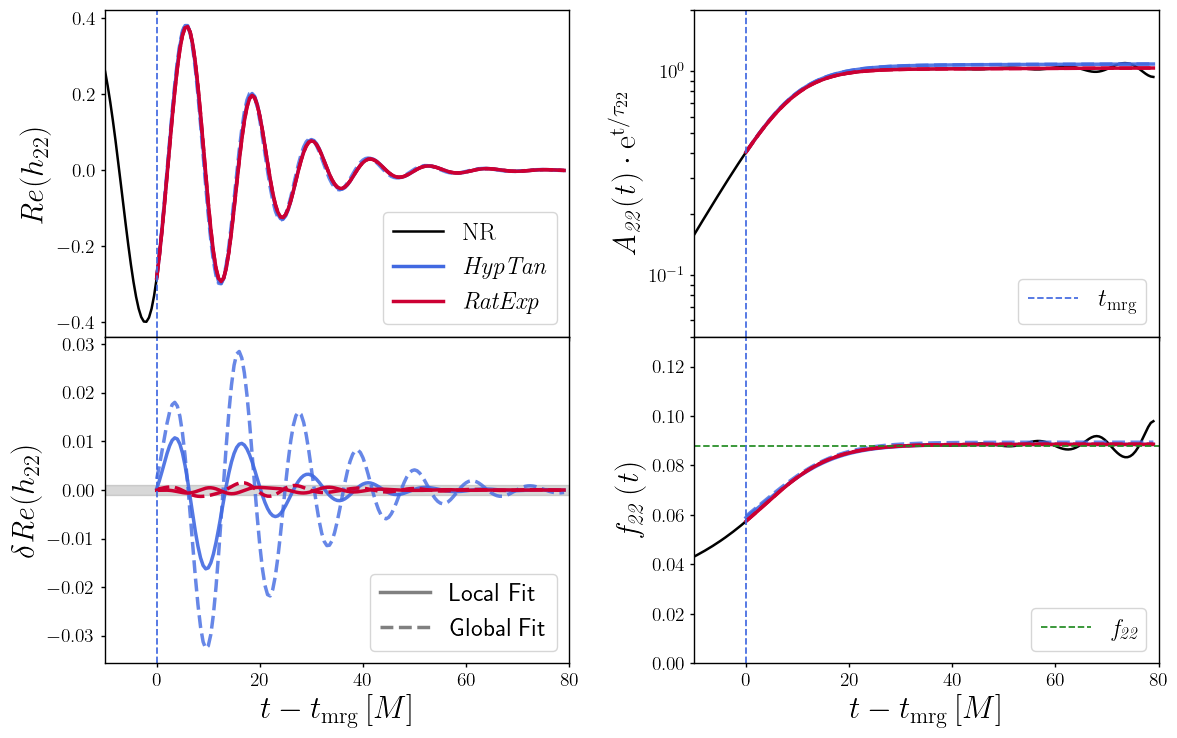

In [11]:
wfs(t_NR, wf.real, wf.imag, q, nu, Mf, af, nc_coeffs, qc_coeffs, nc_coeffs0, qc_coeffs0, t_peak, A_22_mrg, omg_peak, A_22_mrg_ddot, alpha_1, alpha_21, omega_1, label='SXS_2527')

In [12]:
sim = sxs.load('SXS:BBH:2537/Lev3', extrapolation_order=2)
wf = sim.h
metadata = sim.metadata
index = wf.index(2, 2)
wf = wf[:, index]
t_NR = wf.t

In [13]:
q=metadata.initial_mass2/metadata.initial_mass1
nu=q/(1+q)**2
Mf = 0.9712066279552498
af = 0.5412529339652842
A_22_mrg = 0.2864840396766737
omg_peak = 0.3306369767574892
A_22_mrg_ddot = -0.0006715792490769
nc_coeffs = {'c3A': -3.395826578872,
          'c3p': 4.693742163783,
          'c4p': 4.291483363908,
          'c2A': 0.180154453706,
          'c2p': 0.178532068819,
          'phi_0': 1.891990133383}
qc_coeffs = {'c3A': -0.455740625873,
          'c3p': 4.646295376201,
          'c4p': 4.728585213507,
          'phi_0': 1.886443264969}
t_peak = 13651.935091184941
alpha_1 = 0.08499415130226529 
alpha_21 = 0.1731210195964944
omega_1 = 0.47532850179040187

In [14]:
nc_coeffs0 = {'c3A': -3.395826578872,
          'c3p': 4.693742163783,
          'c4p': 4.291483363908,
          'c2A': 0.180154453706,
          'c2p': 0.178532068819,
          'phi_0': 1.891990133383}
qc_coeffs0 = {'c3A': -0.455740625873,
          'c3p': 4.646295376201,
          'c4p': 4.728585213507,
          'phi_0': 1.886443264969}

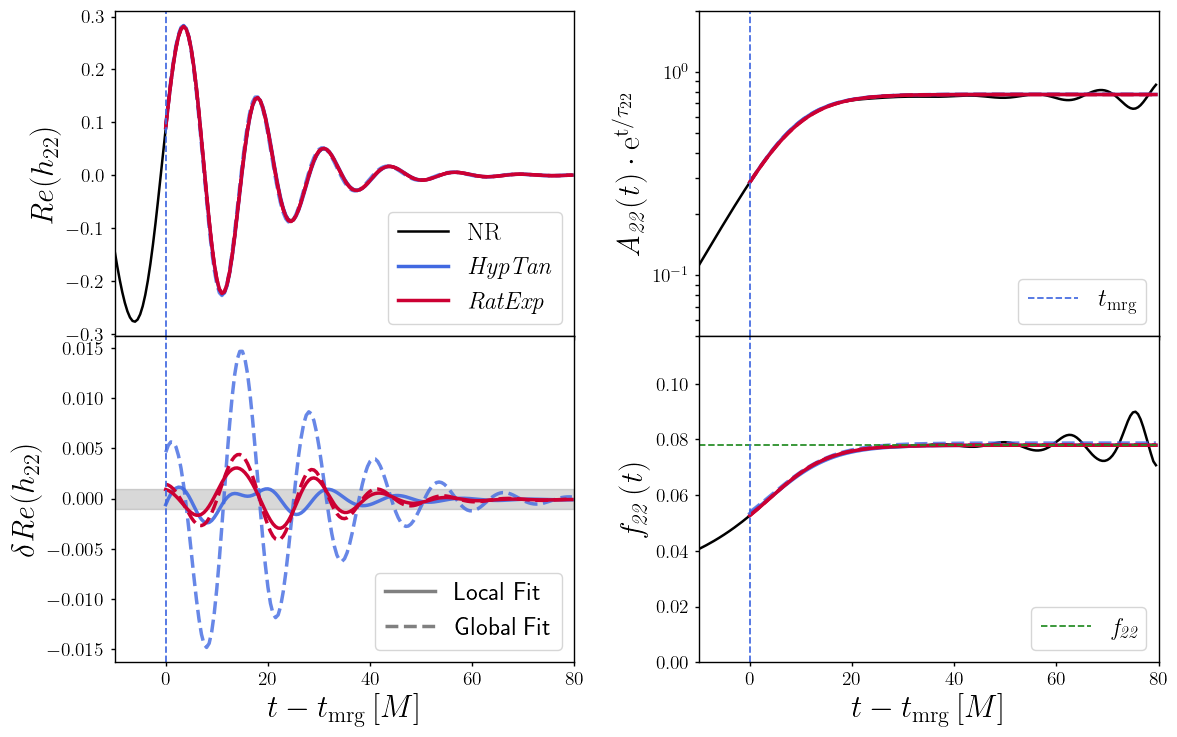

In [15]:
wfs(t_NR, wf.real, wf.imag, q, nu, Mf, af, nc_coeffs, qc_coeffs, nc_coeffs0, qc_coeffs0, t_peak, A_22_mrg, omg_peak, A_22_mrg_ddot, alpha_1, alpha_21, omega_1, label='SXS_2537')